# Visualize the Education's Impact

In [2]:
import os, sys

sys.path.append(os.path.abspath("."))

In [3]:
os.chdir(CURRENT_ADDR := os.path.abspath(".."))

In [4]:
CURRENT_ADDR

'/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article'

## Impact Package

In [98]:
import math
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
import os, sys
import pandas as pd

from glob import glob
from matplotlib import cm

In [73]:
import LoadDataFromDisk

## Function

In [19]:
def read_all_probs_df_from_parquet(results_addr:str) -> dict:
    """
    Read all .parquet files in a directory into a dictionary of DataFrames.

    This function scans the specified directory for all .parquet files, reads each file into a pandas DataFrame,
    and stores them in a dictionary with keys based on the file names (without the .parquet extension).

    Args:
        results_addr (str): The directory path containing .parquet files.

    Returns:
        dict: A dictionary where keys are file names (without extension) and values are pandas DataFrames.
    """
    probs_dictionary = {}
    file_address = sorted(glob(os.path.join(results_addr, '*.parquet')))
    for file in file_address:
        key = os.path.basename(file).replace('.parquet', '')
        probs_dictionary[key] = pd.read_parquet(file)
    return probs_dictionary

In [116]:
def visualize_factual_counterfactual_violin_plots(
    probs_dictionary: dict, 
    input_name_list: list,
    save_address: str
) -> None:
    """
    Visualize violin plots for factual and counterfactual probabilities in a grid.

    Args:
        probs_dictionary (dict): A dictionary containing probability arrays (with keys like 'mean').
        input_name_list (list): A list of factual input names to visualize.
        save_address (str): Path to save the output figure (e.g. 'results/violin_plots.jpg').
    """
    n_plots = len(input_name_list)
    cols = 2
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    sub_figure_code = list("abcdefghijklmnopqrstuvwxyz")

    for idx, input_name in enumerate(input_name_list):
        ax = axes[idx]

        # Extract factual & counterfactual means
        factual = probs_dictionary.get(f'{input_name}')['mean']
        counterfactual = probs_dictionary.get(f'counterfactual_{input_name.split("factual_")[1]}')['mean']
        data = [factual, counterfactual]
        labels = ['Factual', 'Counterfactual']

        # Violin plot
        parts = ax.violinplot(data, showmeans=True, showmedians=True, showextrema=True)
        colors = [cm.viridis(0.2), cm.viridis(0.7)]
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.8)

        # Line colors
        for key, color in {'cmeans': 'orange', 'cmedians': 'red', 'cbars': 'black', 'cmaxes': 'blue', 'cmins': 'blue'}.items():
            if key in parts:
                parts[key].set_color(color)
                parts[key].set_linewidth(1.8 if key in ['cbars'] else 2)

        # Statistics
        means = [np.mean(d) for d in data]
        medians = [np.median(d) for d in data]
        mins = [np.min(d) for d in data]
        maxes = [np.max(d) for d in data]
        positions = np.arange(1, len(data) + 1)

        # Annotate
        for pos, mean, median, minv, maxv in zip(positions, means, medians, mins, maxes):
            texts = [
                ax.text(pos, mean, f"Mean: {mean*100:.2f}%", fontsize=9, va='bottom', ha='center', color='black'),
                ax.text(pos, median, f"Median: {median*100:.2f}%", fontsize=9, va='top', ha='center', color='black'),
                ax.text(pos, maxv, f"Max: {maxv*100:.2f}%", fontsize=9, va='bottom', ha='center', color='black'),
                ax.text(pos, minv, f"Min: {minv*100:.2f}%", fontsize=9, va='top', ha='center', color='black')
            ]
            for t in texts:
                t.set_path_effects([
                    path_effects.Stroke(linewidth=2.5, foreground='white'),
                    path_effects.Normal()
                ])

        # Sub-figure label
        ax.text(0.02, 0.95, f"({sub_figure_code[idx]})", 
                transform=ax.transAxes, fontsize=16, 
                fontweight='bold', va='top', color='black')

        # Axes formatting
        ax.set_xticks([1, 2])
        ax.set_xticklabels(labels)
        ax.set_ylabel('Probability')
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Remove unused subplots
    for ax in axes[n_plots:]:
        ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    # Save figure (300 dpi JPEG)
    plt.savefig(save_address, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Violin plots saved to: {save_address}")

In [117]:
def visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary: dict, 
    input_name_list: list,
    df_stratification: pd.DataFrame,
    labels: list = None,
    save_address: str = "violin_stratification.jpg"
) -> None:
    """
    Visualize violin plots for factual and counterfactual probabilities across stratification groups.

    Args:
        probs_dictionary (dict): A dictionary containing probability arrays (with keys like 'mean').
        input_name_list (list): A list of factual input names to visualize.
        df_stratification (pd.DataFrame): Stratification variable (e.g., gender, age group, province).
        labels (list): Optional custom labels for x-axis (otherwise auto-generated).
        save_address (str): Path to save the output figure (default: 'violin_stratification.jpg').
    """

    n_plots = len(input_name_list)
    cols = 2
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    sub_figure_code = list("abcdefghijklmnopqrstuvwxyz")

    for idx, input_name in enumerate(input_name_list):
        ax = axes[idx]

        # Extract factual & counterfactual means
        factual = probs_dictionary.get(f'{input_name}')['mean']
        counterfactual = probs_dictionary.get(f'counterfactual_{input_name.split("factual_")[1]}')['mean']
        strat_var = df_stratification.iloc[:, 0]

        # Unique groups
        groups = sorted(strat_var.unique())

        # Build data dynamically (handles any number of groups)
        data = []
        x_labels = []
        for fc_label, arr in zip(['Factual', 'Counterfactual'], [factual, counterfactual]):
            for g in groups:
                data.append(arr[strat_var == g])
                x_labels.append(f"{fc_label} - {g}")

        # Violin plot
        parts = ax.violinplot(data, showmeans=True, showmedians=True, showextrema=True)
        cmap_positions = np.linspace(0.15, 0.85, len(data))
        colors = [cm.viridis(c) for c in cmap_positions]
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.8)

        # Line colors
        for key, color in {'cmeans': 'orange', 'cmedians': 'red', 'cbars': 'black',
                           'cmaxes': 'blue', 'cmins': 'blue'}.items():
            if key in parts:
                parts[key].set_color(color)
                parts[key].set_linewidth(1.8 if key == 'cbars' else 2)

        # Statistics
        means = [np.mean(d) for d in data]
        medians = [np.median(d) for d in data]
        mins = [np.min(d) for d in data]
        maxes = [np.max(d) for d in data]
        positions = np.arange(1, len(data) + 1)

        # Annotate (with white edges)
        for pos, mean, median, minv, maxv in zip(positions, means, medians, mins, maxes):
            texts = [
                ax.text(pos - 0.04, mean, f"Mean: {mean*100:.2f}%", fontsize=9, va='bottom', ha='center', color='black'),
                ax.text(pos - 0.04, median, f"Median: {median*100:.2f}%", fontsize=9, va='top', ha='center', color='black'),
                ax.text(pos - 0.04, maxv, f"Max: {maxv*100:.2f}%", fontsize=9, va='bottom', ha='center', color='black'),
                ax.text(pos - 0.04, minv, f"Min: {minv*100:.2f}%", fontsize=9, va='top', ha='center', color='black')
            ]
            for t in texts:
                t.set_path_effects([
                    path_effects.Stroke(linewidth=2.5, foreground='white'),
                    path_effects.Normal()
                ])

        # Subplot label (e.g. a, b, c…)
        ax.text(
            0.02, 0.95, f"({sub_figure_code[idx]})",
            transform=ax.transAxes, fontsize=15,
            fontweight='bold', va='top', color='black'
        )

        # Axis setup (no titles)
        ax.set_xticks(np.arange(1, len(data) + 1))
        ax.set_xticklabels(labels if labels else x_labels, rotation=15, ha='center')
        ax.set_ylabel('Probability')
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Remove unused subplots
    for ax in axes[n_plots:]:
        ax.axis('off')

    # Layout and save (no figure title)
    plt.tight_layout()
    plt.savefig(save_address, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Violin plots saved to: {save_address}")

## Run

In [5]:
if __name__ == '__main__':
    pass

In [6]:
os.makedirs(MLD01e1_RESULTS_ADDR := './MLD01e_Results/MLD01e1_Results', exist_ok=True)

In [20]:
probs_dictionary = read_all_probs_df_from_parquet(MLD01e1_RESULTS_ADDR)

In [44]:
input_name_list = ['factual_knowledge_probs', 'factual_awareness_probs', 
                   'factual_action_probs_soilandwater', 'factual_action_probs_riskreduction', 
                   'factual_action_probs_roadimprovement', 'factual_action_probs_communityparticipation']

### Total Effect

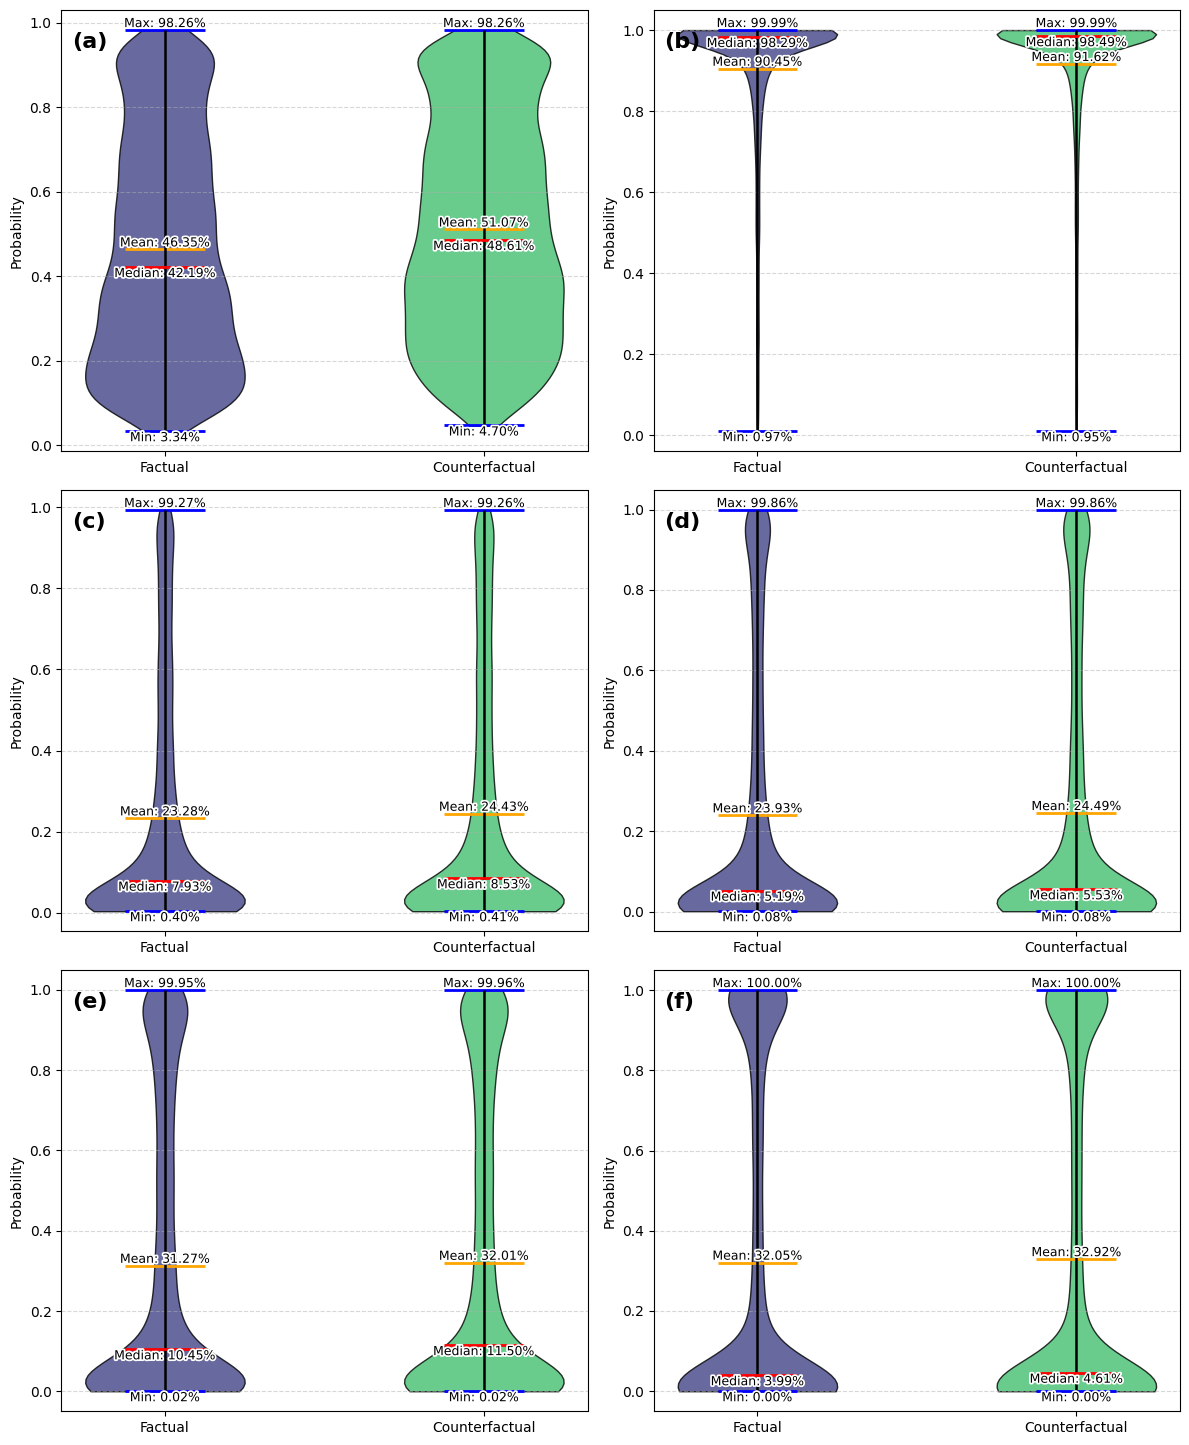

✅ Violin plots saved to: ./MLD01e_Figures/FigureXX_factual_counterfactual_violin_plots.jpg


In [118]:
visualize_factual_counterfactual_violin_plots(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    save_address='./MLD01e_Figures/FigureXX_factual_counterfactual_violin_plots.jpg'
    )

### Visualize Gender effect

In [119]:
df_stratification = LoadDataFromDisk.load_data_from_disk()[['Respon_Female']].reset_index(drop=True)

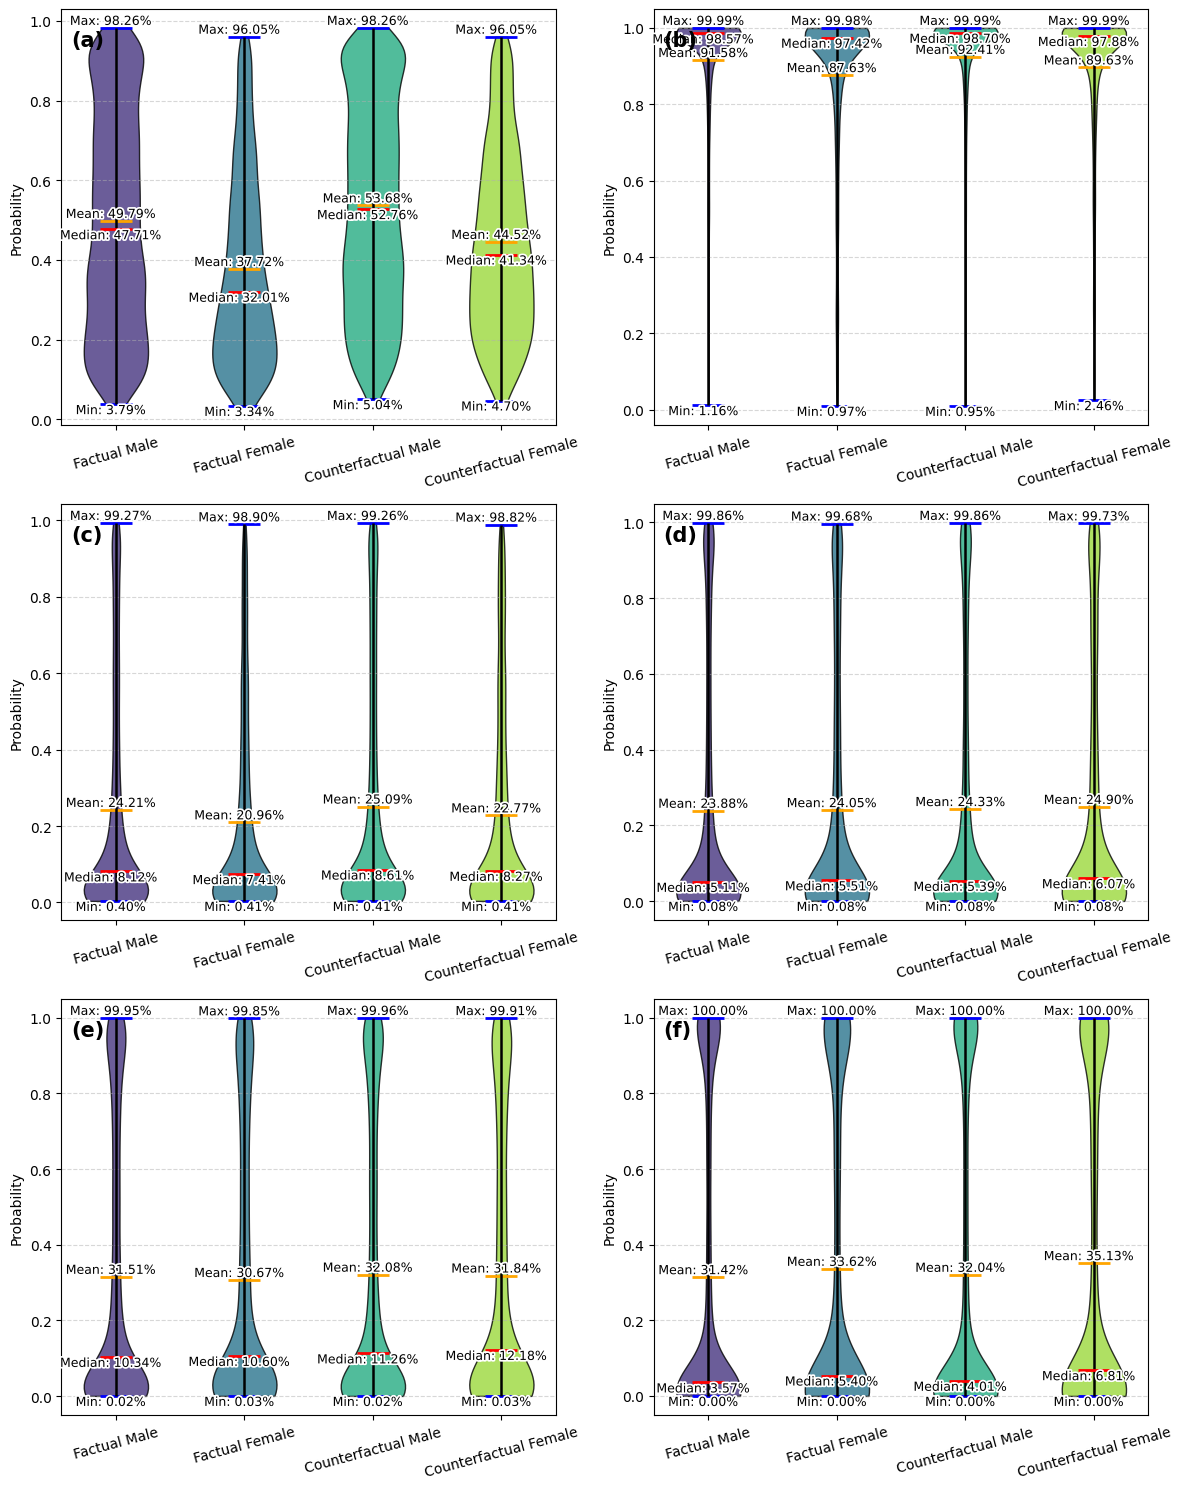

✅ Violin plots saved to: ./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_gender.jpg


In [121]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    labels=['Factual Male', 'Factual Female', 'Counterfactual Male', 'Counterfactual Female'],
    save_address='./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_gender.jpg'
    )

### Visualize Senior

In [123]:
df_all = LoadDataFromDisk.load_data_from_disk()

In [129]:
print(df_all.columns[:40])

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year',
       'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio',
       'Literal_Ratio', 'Household_memberNum', 'Own_Resid', 'Resid_Type',
       'WaterS1', 'WaterS2', 'WaterS3', 'CookFuelS1', 'CookFuelS2',
       'CookFuelS3', 'LightEnergy', 'Toilet', 'IncomeS1', 'IncomeS2',
       'IncomeS3', 'Remittance_dummy', 'Have_AgriLand', 'Radio_dummy',
       'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy'],
      dtype='object')


In [125]:
# Load data and keep only Respon_Age
df_stratification = LoadDataFromDisk.load_data_from_disk()[['Respon_Age']].reset_index(drop=True)

# Create dummy: 1 if age > 65, else 0
df_stratification['Above65_Dummy'] = (df_stratification['Respon_Age'] > 65).astype(int)
df_stratification = df_stratification[['Above65_Dummy']]

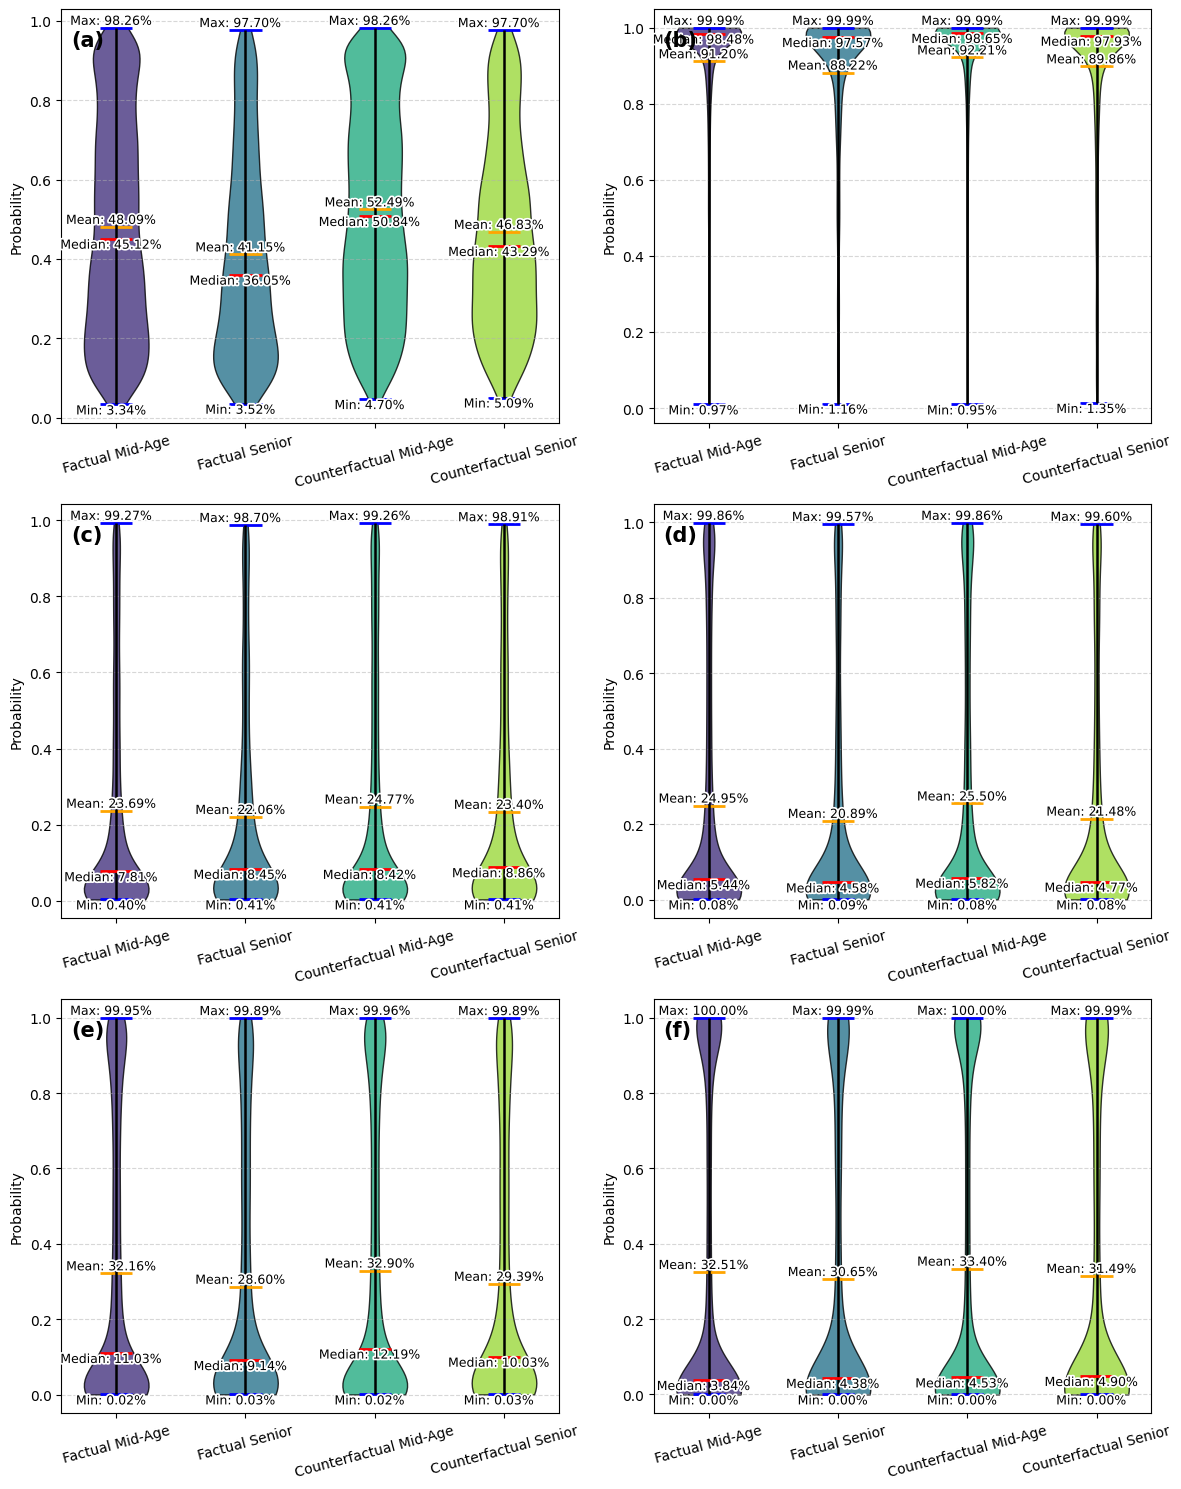

✅ Violin plots saved to: ./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_senior.jpg


In [126]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    labels=['Factual Mid-Age', 'Factual Senior', 'Counterfactual Mid-Age', 'Counterfactual Senior'],
    save_address='./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_senior.jpg'
    )

### Visualize Rural effect

In [130]:
df_stratification = LoadDataFromDisk.load_data_from_disk()[['Rural_Dummy']].reset_index(drop=True)

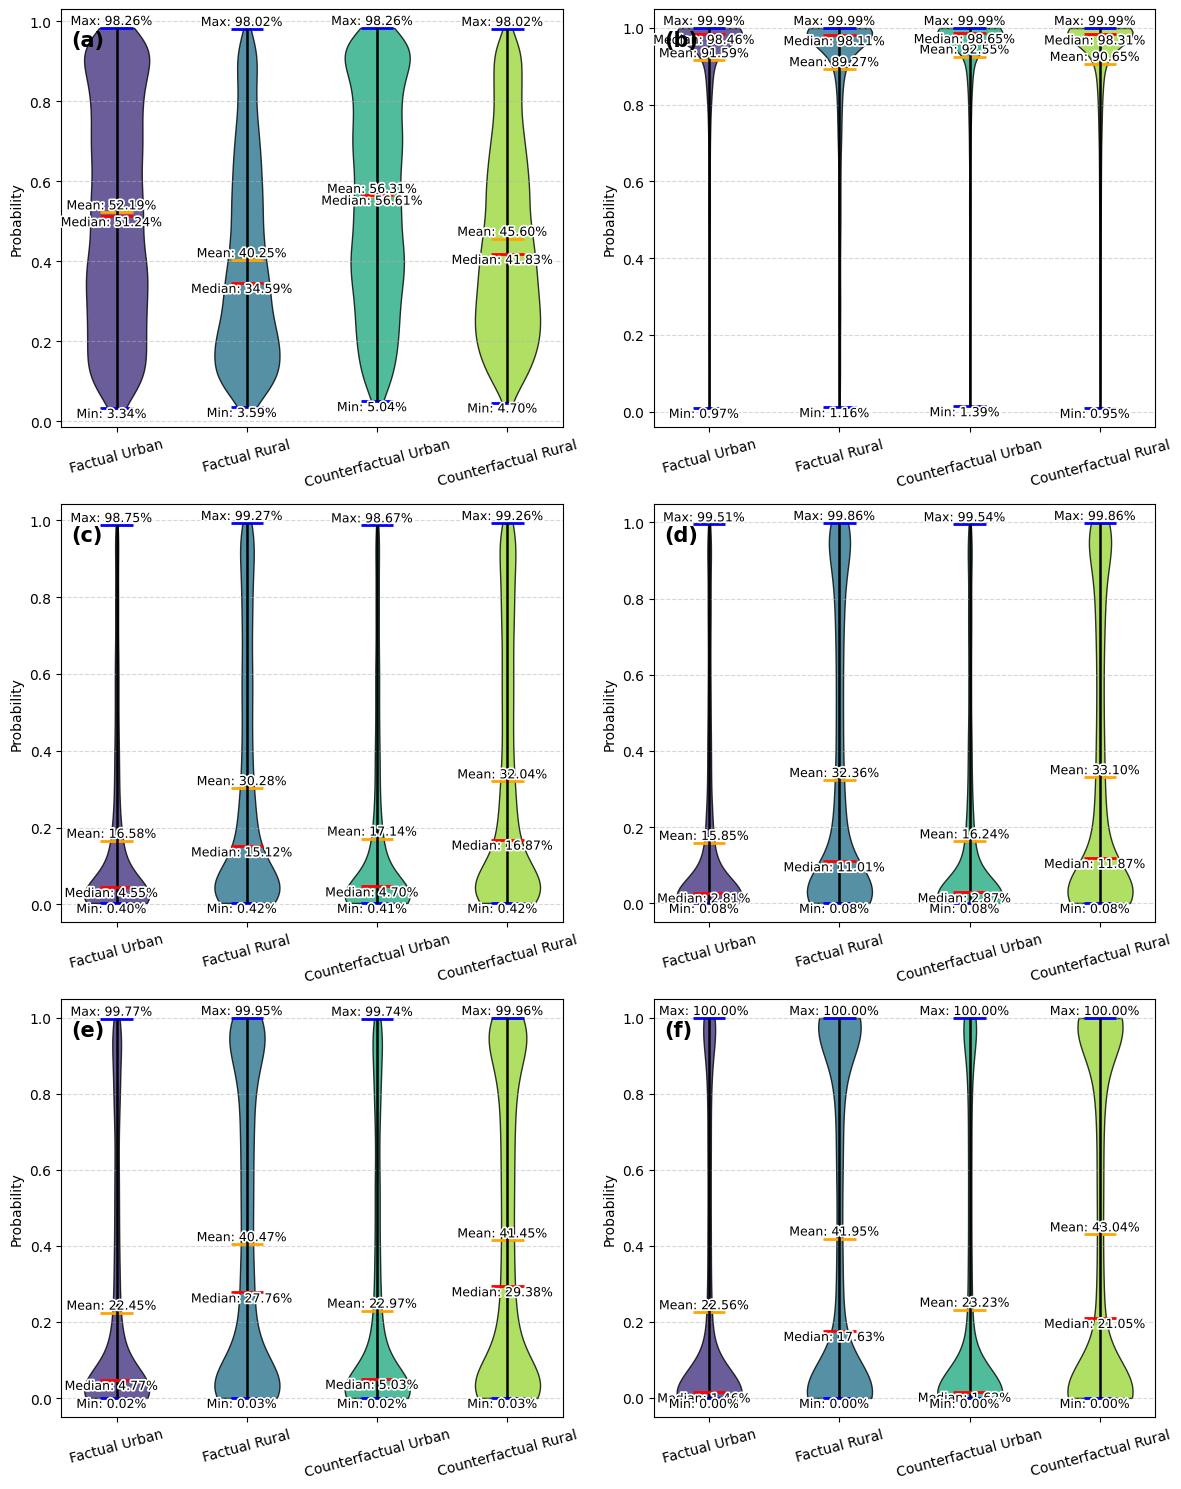

✅ Violin plots saved to: ./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_rural.jpg


In [131]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    labels=['Factual Urban', 'Factual Rural', 'Counterfactual Urban', 'Counterfactual Rural'],
    save_address='./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_rural.jpg'
    )

### Visualize Total Income

In [133]:
df_all = LoadDataFromDisk.load_data_from_disk()

In [136]:
df_all['TotalIncome'].describe()

count    1.156800e+04
mean     3.239423e+05
std      1.143592e+06
min      0.000000e+00
25%      5.400000e+04
50%      1.700000e+05
75%      4.000000e+05
max      9.920000e+07
Name: TotalIncome, dtype: float64

In [140]:
# Load data and keep only Respon_Age
df_stratification = LoadDataFromDisk.load_data_from_disk()[['TotalIncome']].reset_index(drop=True)

# Create dummy: 1 if age > 65, else 0
df_stratification['HighIncome_Dummy'] = (df_stratification['TotalIncome'] > 1.700000e+05).astype(int)
df_stratification = df_stratification[['HighIncome_Dummy']]

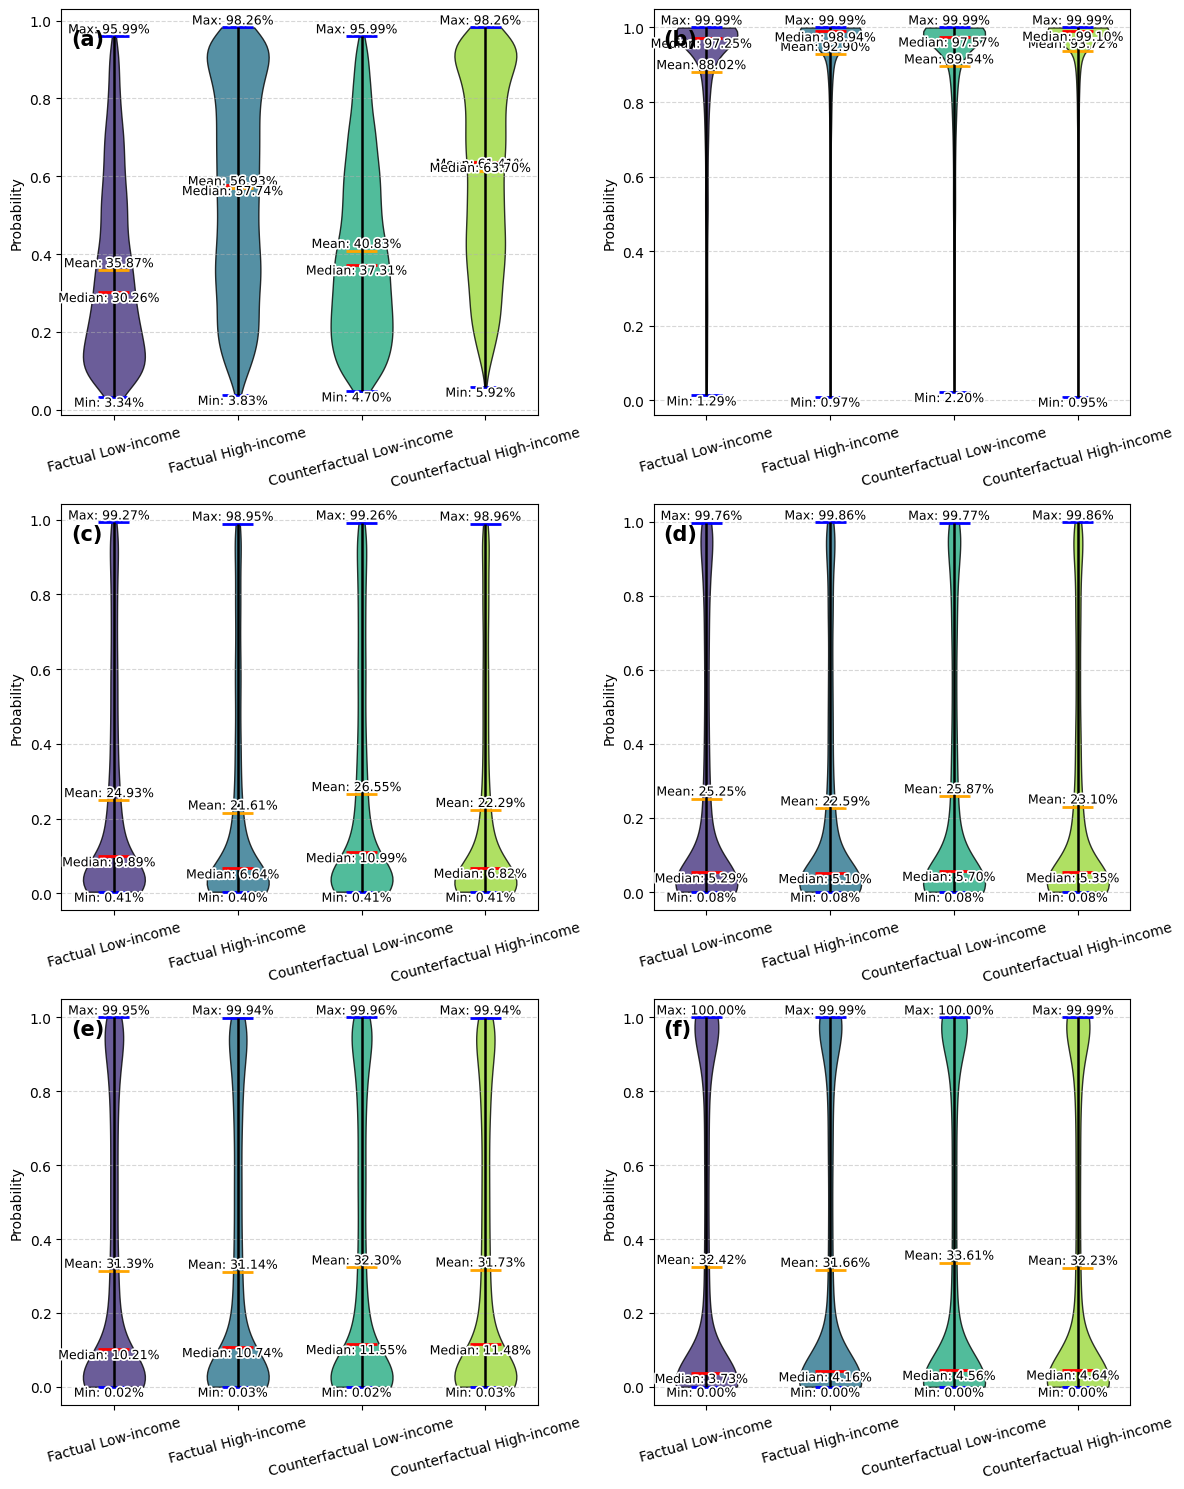

✅ Violin plots saved to: ./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_income.jpg


In [141]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    labels=['Factual Low-income', 'Factual High-income', 'Counterfactual Low-income', 'Counterfactual High-income'],
    save_address='./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_income.jpg'
    )